## Unbiased Random Walk on a Network

This notebook contains a basic implementation of a random walk on a `networkx.DiGraph` object.

The notebook also implements:
- Walk lengths sampled from arbitrary discrete distributions
- Unbiased and biased random walks (arbitrary transition matrix)

In [140]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd

rng = np.random.default_rng(seed=42)

In [148]:
# Load the geographical district network from the neighbour table
geographical_neighbours = pd.read_csv('data/geographical_neighbours.csv')
G_geo = nx.from_pandas_edgelist(
    geographical_neighbours,
    source='focal',
    target='neighbour',
    edge_attr=['road_connected', 'src_vx', 'tgt_vx', 'src_distance', 'tgt_distance', 'in_distance', 'road_distance'],
    create_using=nx.Graph()
)

In [149]:
G_geo.nodes()

NodeView((0, 1, 2, 71, 72, 73, 3, 4, 5, 6, 8, 31, 7, 30, 16, 17, 32, 62, 9, 53, 56, 10, 13, 15, 47, 11, 14, 49, 12, 48, 65, 18, 19, 29, 58, 60, 61, 36, 20, 21, 24, 41, 43, 22, 23, 45, 25, 27, 26, 28, 33, 52, 55, 54, 34, 35, 37, 39, 57, 38, 40, 42, 44, 46, 64, 51, 50, 63, 59, 67, 68, 66, 69, 70))

In [21]:
def random_walk(transition_matrix, start_node, walk_length, rng=None):
    """
    Return a random walk on the graph encoded in the `transition_matrix`.
    
    Returns a Python list of node indices.

    transition_matrix   (np.ndarray): A 2D numpy array encoding the transition probabilities between nodes.
                                      That is, row i, column j of the transition_matrix encodes the 
                                      probability of going to j from i. The transition matrix is assumed 
                                      to be normalized (an exception is thrown otherwise).
    start_node          (int)       : The index of the starting node.
    walk_length         (int)       : The length of the random walk.
    """
    if rng is None:
        rng = np.random.default_rng()

    if start_node >= len(transition_matrix) or start_node < 0:
        raise ValueError(f"start_node with index {start_node!r} is not in the graph")
    
    # Check if transition matrix is 'proper', i.e. normalized by row
    for row in transition_matrix:
        if not np.isclose(np.sum(row), 1):
            raise ValueError("Transition matrix is not normalized by row.")

    path = [start_node]
    current_node = start_node

    for _ in range(walk_length):
        transition_probs = transition_matrix[current_node]
        if not np.any(transition_probs):
            break
        current_node = rng.choice(len(transition_probs), p=transition_probs)
        path.append(int(current_node))

    return path

In [41]:
### Unbiased walk as example

G_geo_transitions = nx.to_numpy_array(G_geo, nodelist=sorted(G_geo.nodes()))    # Adjacency matrix
G_geo_transitions /= np.sum(G_geo_transitions, axis=1, keepdims=True)   # Normalize to obtain transition matrix

walk = random_walk(transition_matrix=G_geo_transitions, start_node=0, walk_length=10**5, rng=rng)
walk

[0,
 71,
 70,
 69,
 67,
 71,
 0,
 73,
 69,
 70,
 71,
 73,
 0,
 71,
 73,
 0,
 72,
 73,
 72,
 73,
 72,
 1,
 3,
 1,
 2,
 1,
 0,
 73,
 71,
 67,
 63,
 67,
 63,
 68,
 63,
 50,
 63,
 68,
 63,
 50,
 71,
 50,
 71,
 0,
 71,
 70,
 71,
 50,
 51,
 65,
 48,
 15,
 47,
 46,
 44,
 43,
 41,
 43,
 21,
 43,
 24,
 31,
 6,
 8,
 4,
 6,
 4,
 8,
 6,
 8,
 4,
 6,
 31,
 20,
 21,
 43,
 24,
 31,
 24,
 22,
 24,
 20,
 24,
 21,
 24,
 22,
 45,
 43,
 24,
 22,
 32,
 31,
 22,
 23,
 32,
 31,
 32,
 6,
 16,
 19,
 29,
 16,
 29,
 26,
 30,
 29,
 26,
 30,
 7,
 30,
 7,
 30,
 5,
 4,
 6,
 32,
 52,
 54,
 55,
 54,
 33,
 55,
 33,
 54,
 52,
 54,
 33,
 55,
 33,
 52,
 54,
 53,
 9,
 53,
 55,
 54,
 53,
 9,
 56,
 9,
 53,
 9,
 53,
 55,
 62,
 55,
 54,
 53,
 54,
 52,
 54,
 53,
 9,
 53,
 56,
 60,
 58,
 60,
 17,
 6,
 62,
 55,
 54,
 53,
 56,
 62,
 55,
 62,
 56,
 9,
 53,
 9,
 53,
 54,
 53,
 56,
 53,
 55,
 32,
 31,
 32,
 52,
 32,
 22,
 32,
 52,
 32,
 31,
 32,
 52,
 33,
 55,
 33,
 32,
 55,
 62,
 32,
 22,
 45,
 43,
 41,
 46,
 64,
 48,
 64,
 66,
 65,


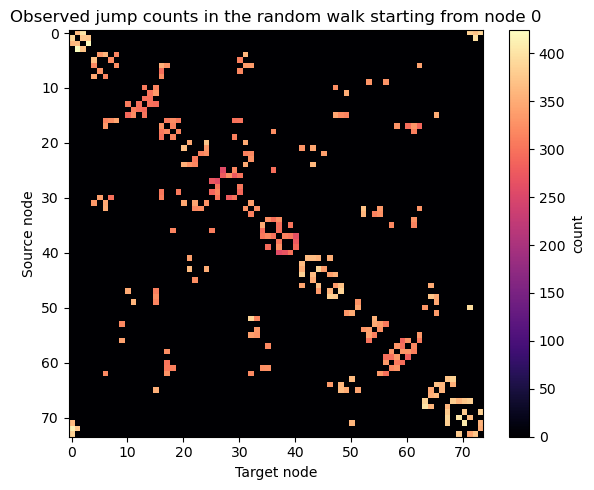

In [43]:
def count_jumps(walk, node_order=None):
    """
    Count observed jumps between nodes in a walk.

    walk (list): A list of node labels representing the walk.
    node_order (list, optional): The full list of node labels in desired order of output matrix indices.
                                 If None, all unique nodes in the walk are used and the indices 
                                 correspond to sorted node labels.
    """
    if node_order is None:
        node_order = sorted(set(walk))

    node_to_idx = {node: idx for idx, node in enumerate(node_order)}
    counts = np.zeros((len(node_order), len(node_order)), dtype=int)

    for source_node, target_node in zip(walk[:-1], walk[1:]):   # TODO: Could be more memory efficient
        if source_node in node_to_idx and target_node in node_to_idx:
            counts[node_to_idx[source_node], node_to_idx[target_node]] += 1

    return counts

node_order = sorted(G_geo.nodes())
jump_counts = count_jumps(walk, node_order=node_order)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(jump_counts, cmap='magma', interpolation='nearest', aspect='auto')
ax.set_title(f'Observed jump counts in the random walk starting from node {walk[0]}')
ax.set_xlabel('Target node')
ax.set_ylabel('Source node')
fig.colorbar(im, ax=ax, label='count')
plt.tight_layout()
plt.show()

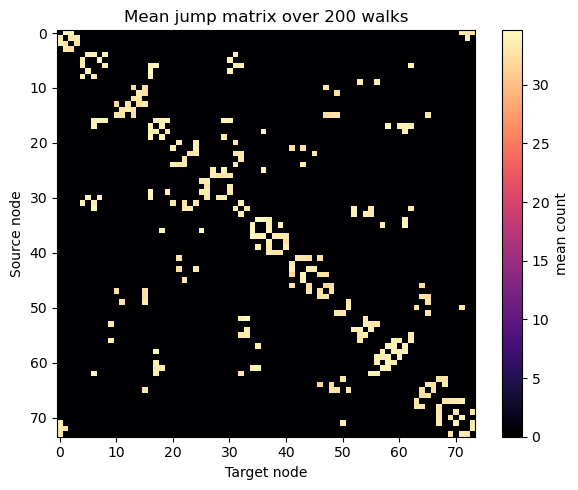

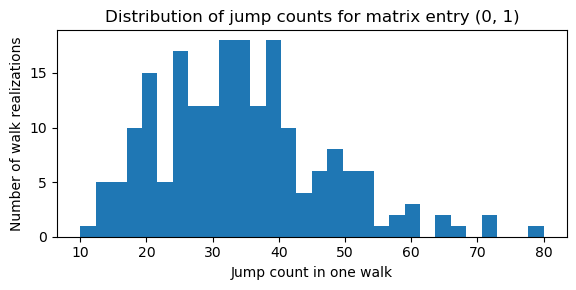

In [ ]:
# Jump distributions over multiple walks

n_walks = 200
walk_length = 10000

jump_matrices = np.zeros((n_walks, len(node_order), len(node_order)), dtype=int)
for walk_idx in range(n_walks):
    start_node = rng.integers(low=0, high=len(node_order))
    sampled_walk = random_walk(G_geo_transitions, start_node=start_node, walk_length=walk_length, rng=rng)
    jump_matrices[walk_idx] = count_jumps(sampled_walk, node_order=node_order)

mean_jump_matrix = jump_matrices.mean(axis=0)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(mean_jump_matrix, cmap='magma', interpolation='nearest', aspect='auto')
ax.set_title(f'Mean jump matrix over {n_walks} walks')
ax.set_xlabel('Target node')
ax.set_ylabel('Source node')
fig.colorbar(im, ax=ax, label='mean count')
plt.tight_layout()
plt.show()


i_index = 0
j_index = 1


fig, ax = plt.subplots(figsize=(6, 3))

# jump_counts_ij = jump_matrices[:, i_index, j_index]
# jump_counts_ij_series = pd.Series(jump_counts_ij, name=f'entry_{i_index}_{j_index}')
# values, frequencies = np.unique(jump_counts_ij, return_counts=True)
# ax.bar(values.astype(int), frequencies, width=0.8)
# ax.bar(height=vals, x=np.diff(edges), width=0.8)

vals, edges = np.histogram(jump_matrices[:, i_index, j_index], bins=30)
ax.bar(edges[:-1], vals, width=np.diff(edges), align='edge')

ax.set_title(f'Distribution of jump counts for matrix entry ({i_index}, {j_index})')
ax.set_xlabel('Jump count in one walk')
ax.set_ylabel('Number of walk realizations')
plt.tight_layout()
plt.show()

# jump_counts_ij_series

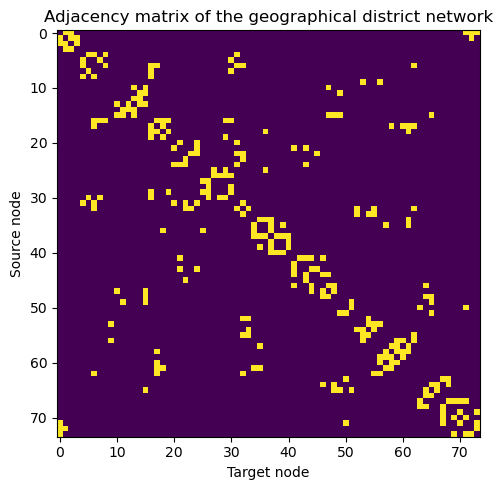

In [ ]:
# Compare to adjacency matrix of the geographical district network
node_order = sorted(G_geo.nodes())
adjacency_matrix = nx.to_numpy_array(G_geo, nodelist=node_order, dtype=int)

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(adjacency_matrix, cmap='viridis', interpolation='nearest', aspect='auto')
ax.set_title('Adjacency matrix of the geographical district network')
ax.set_xlabel('Target node')
ax.set_ylabel('Source node')
# fig.colorbar(im, ax=ax, label='Edge presence')
plt.tight_layout()
plt.show()

## Flow network

In [402]:
# Import geographical flow data
geo_flow_matrix = np.loadtxt('data/geo_flow_matrix.csv', delimiter=',', dtype=int)
geo_flow_labels = np.loadtxt('data/geo_labels_gadm.csv', delimiter=',', dtype=str)
gadm_id_to_label = {int(id): str(label) for id, label in geo_flow_labels}

# Create networkx Graph from flow data
indices = geo_flow_labels[:, 0].astype(int).tolist()
G_flows = nx.from_numpy_array(geo_flow_matrix, create_using=nx.DiGraph(), nodelist=indices, edge_attr='IDP_flow')
for id, name in geo_flow_labels:
    G_flows.nodes[int(id)]['name'] = str(name)

In [403]:
G_flows.nodes(data=True)

NodeDataView({0: {'name': 'Baki'}, 1: {'name': 'Boorama'}, 2: {'name': 'Lughaya'}, 3: {'name': 'Zeylac'}, 4: {'name': 'CeelBarde'}, 5: {'name': 'RabDhuure'}, 6: {'name': 'Tiyeeglow'}, 7: {'name': 'Wajid'}, 8: {'name': 'Xudur'}, 9: {'name': 'Mogadisho'}, 10: {'name': 'Bander-Beyla'}, 11: {'name': 'Bosaaso'}, 12: {'name': 'Calawla'}, 13: {'name': 'Iskushuban'}, 14: {'name': 'Qandala'}, 15: {'name': 'Qardho'}, 16: {'name': 'Baydhabo'}, 17: {'name': 'BuurXakaba'}, 18: {'name': 'Diinsoor'}, 19: {'name': 'QansaxDheere'}, 20: {'name': 'Caabudwaaq'}, 21: {'name': 'Cadaado'}, 22: {'name': 'CeelBuur'}, 23: {'name': 'CeelDheer'}, 24: {'name': 'Dhuusamareeb'}, 25: {'name': 'Baar-Dheere'}, 26: {'name': 'BeledXaawo'}, 27: {'name': 'CeelWaaq'}, 28: {'name': 'Dolow'}, 29: {'name': 'Garbahaaray'}, 30: {'name': 'Luuk'}, 31: {'name': 'BeledWeyn'}, 32: {'name': 'BuuloBurdo'}, 33: {'name': 'Jalalaqsi'}, 34: {'name': "Bu'aale"}, 35: {'name': 'Jilib'}, 36: {'name': 'Saakow'}, 37: {'name': 'Afmadow'}, 38: {'n

### Walk length distributions from data

In [405]:
# Limit of distribution will is diameter (maximum shortest path length)
diameter = nx.diameter(G_geo)
print(f"Diameter of the geographical district network: {diameter}")

shortest_path_length_dist = {id : np.zeros(diameter + 1) for id in G_flows.nodes()}
node_outflows = G_flows.out_degree(weight='IDP_flow') # Get the outflow (sum of weights of outgoing edges) for each node

# Calculate shortest path lengths between pairs and weigh by normalized flow
for o, d, w in G_flows.edges(data=True) :
    l = nx.shortest_path_length(G_geo, source=o, target=d)
    shortest_path_length_dist[o][l] += w['IDP_flow'] / node_outflows[o]

Diameter of the geographical district network: 17


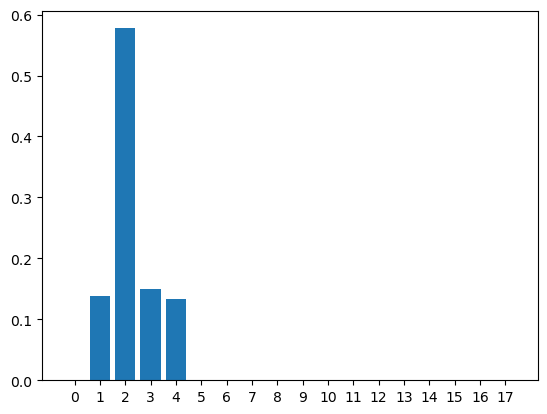

In [406]:
node_id = 4
plt.bar(np.arange(diameter + 1), shortest_path_length_dist[node_id])
plt.xticks(np.arange(diameter + 1));

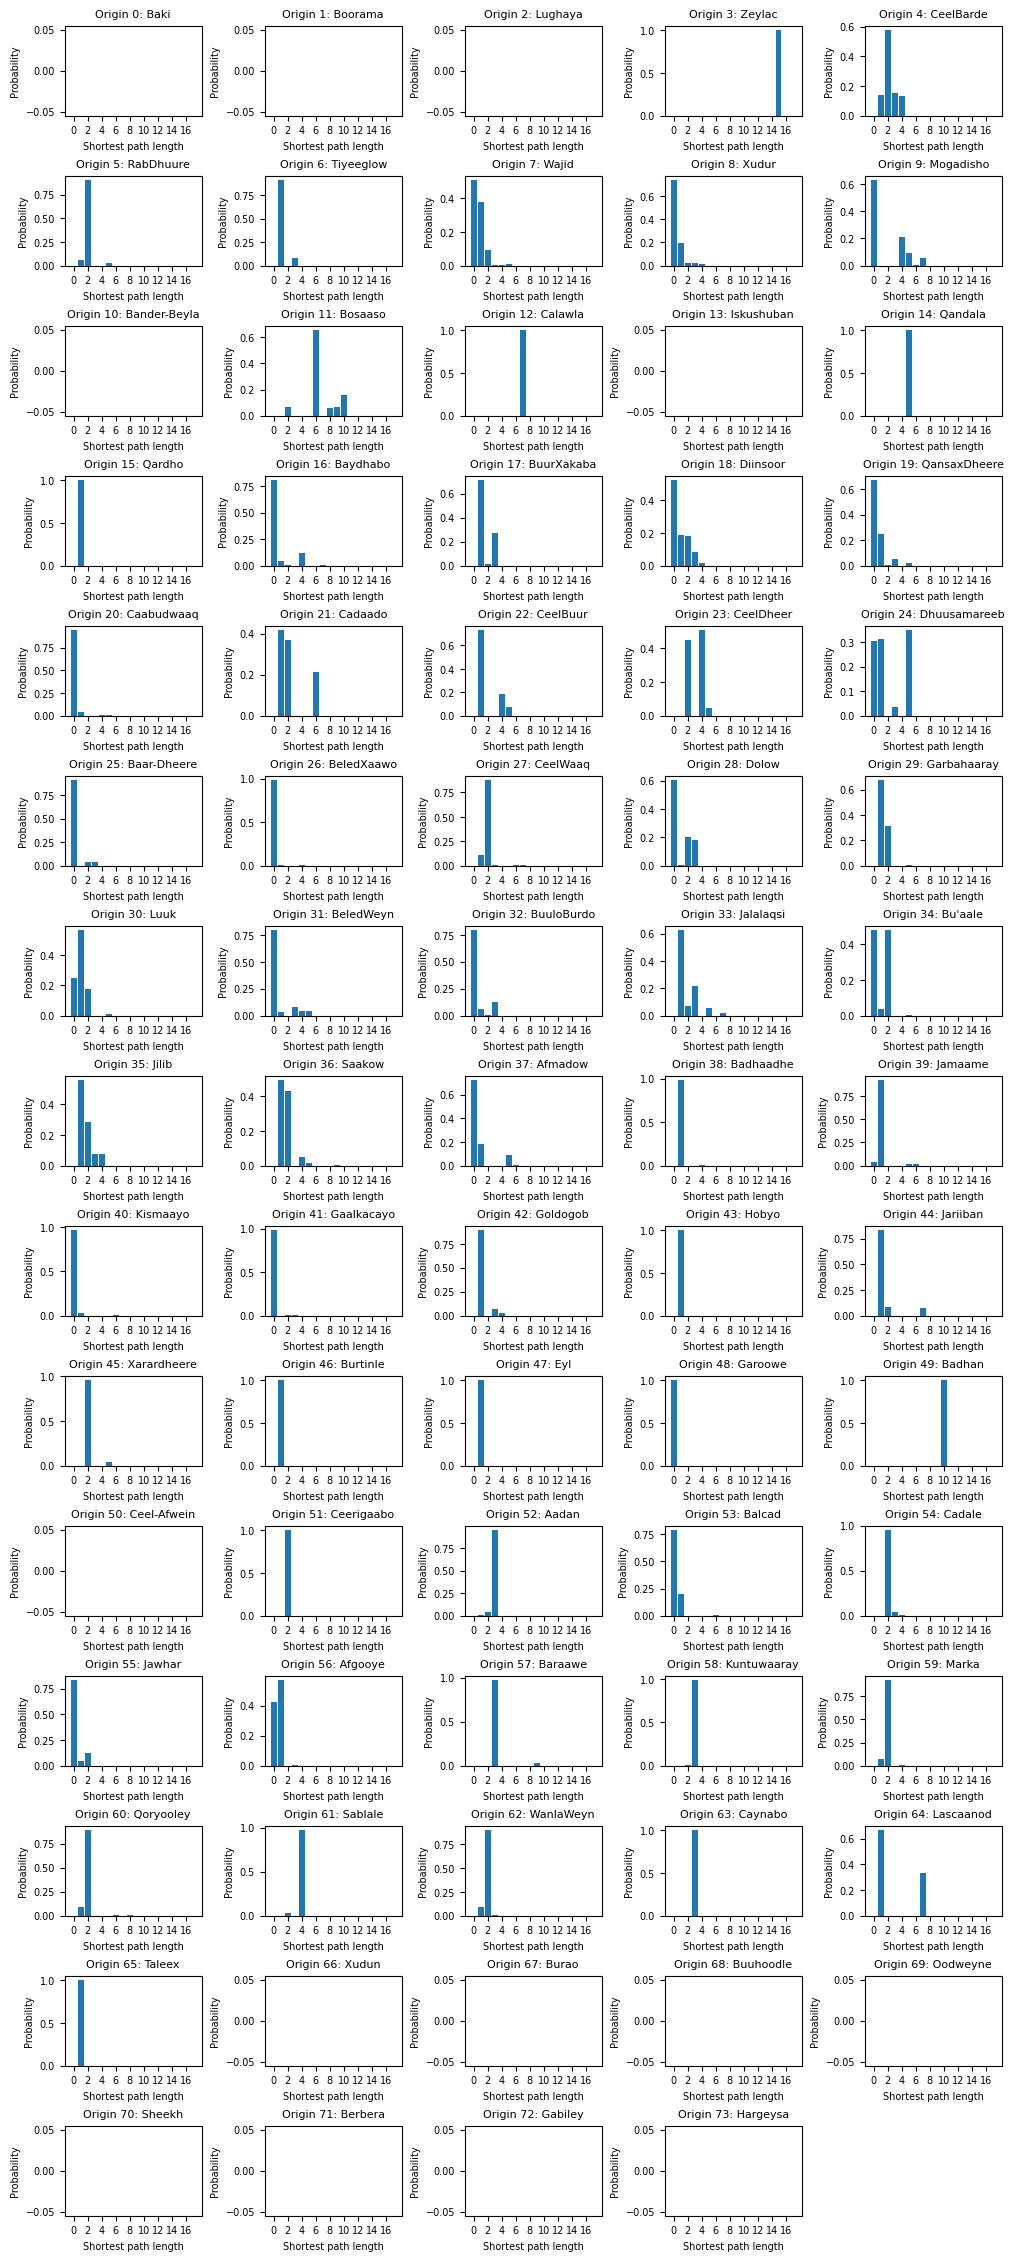

In [421]:
# Create a grid of subplots, one for each node
n_nodes = len(node_order)
n_cols = 5
n_rows = (n_nodes + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2, n_rows * 1.5), layout='constrained')
axes = axes.flatten()  # Flatten to make indexing easier

for idx, node_id in enumerate(node_order):
    ax = axes[idx]
    ax.bar(np.arange(diameter + 1), shortest_path_length_dist[node_id])
    ax.set_xticks(np.arange(0, diameter + 1, 2))
    ax.set_title(f'Origin {node_id}: {geo_flow_labels[node_id, 1]}', fontsize=8)
    ax.set_xlabel('Shortest path length', fontsize=7)
    ax.set_ylabel('Probability', fontsize=7)
    ax.tick_params(labelsize=7)

# Hide any unused subplots
for idx in range(n_nodes, len(axes)):
    axes[idx].set_visible(False)

# plt.tight_layout()

# plt.savefig('figs/path_length_distributions_shortest_path.pdf', dpi=300)
plt.savefig('figs/path_length_distributions_shortest_path.png', dpi=600)

## RW model

### Walks with fixed length distribution

In [408]:
N = G_geo.number_of_nodes()
flow_matrix = np.zeros((N, N))

for start_node in range(N) :
    #### Placeholder: Here we would sample length from the node-specific distribution ####
    walk_lengths = rng.integers(1, 11, size=10**3)
    ####
    for walk_length in walk_lengths :
        # Simulate walk via transition matrix from geographical neighbors network
        walk = random_walk(G_geo_transitions, start_node=start_node, walk_length=walk_length, rng=rng)
        flow_matrix[start_node, walk[-1]] += 1

# Normalize flow matrix
flow_matrix /= np.sum(flow_matrix, axis=1, keepdims=True)
flow_matrix

array([[0.161, 0.14 , 0.092, ..., 0.097, 0.114, 0.096],
       [0.176, 0.159, 0.152, ..., 0.054, 0.119, 0.079],
       [0.175, 0.188, 0.129, ..., 0.068, 0.117, 0.084],
       ...,
       [0.083, 0.065, 0.047, ..., 0.104, 0.042, 0.069],
       [0.181, 0.163, 0.096, ..., 0.093, 0.112, 0.111],
       [0.141, 0.102, 0.056, ..., 0.116, 0.085, 0.095]], shape=(74, 74))

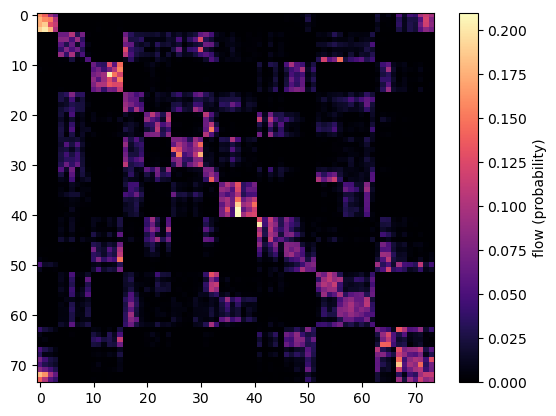

In [409]:
plt.imshow(flow_matrix, cmap='magma', aspect='auto')
plt.colorbar(label='flow (probability)')

### First passage time distributions

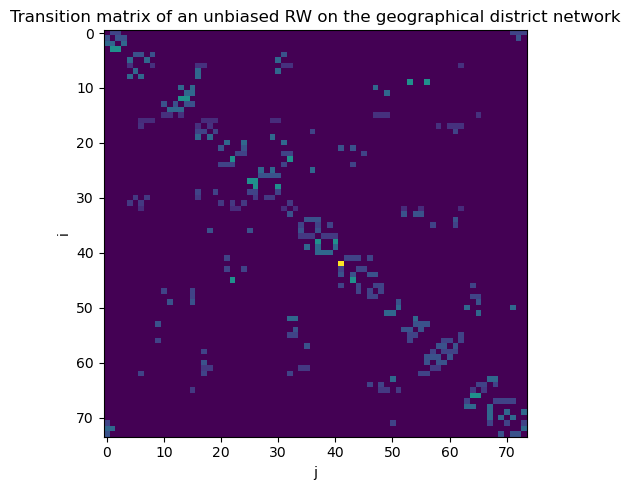

In [410]:
# Transition matrix for an unbiased RW on geographical network

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(G_geo_transitions, cmap='viridis', interpolation='nearest', aspect='auto')
ax.set_title('Transition matrix of an unbiased RW on the geographical district network')
ax.set_xlabel('j')
ax.set_ylabel('i')
# fig.colorbar(im, ax=ax, label='Edge presence')
plt.tight_layout()
plt.show()

The code below uses the iterative (renewal) method to calculate the first passage time distribution (the probability of starting from i and going to j for the first time in exactly n steps).

Concretely, we have the transition matrix $T$, and we define $p_{ij}^{(n)}=\{T^n\}_{ij}$. Then the probability of starting at state (node) $i$ and ending at $j$ in exactly $n$ steps is denoted by $f_{ij}^{(n)}$ and calculated as $$f_{ij}^{(n)}=p_{ij}^{(n)} - \sum_{\ell=1}^{n-1}f_{ij}^{(\ell)}p_{jj}^{(n-\ell)}.$$

This is what we consider the first passage time distribution, with the caveat that for computational reasons we set a threshold for the probability which we use to truncate the domain $n$ of the distribution, and normalize all of the probabilities up to then (see the `stop` parameter in `fpt_distribution()`).

In [411]:
def fpt_distribution(i, j, T, stop=1e-10) :
    """
    Calculate the distribution of first passage times (fpt) from state i to state j, given transition matrix T.

    i (int): The index of the starting state.
    j (int): The index of the target state.
    T (numpy.ndarray): The transition matrix.
    stop (float): The stopping criterion for the iteration. 
                  If the fpt probability at step n is less than or equal to this value, 
                  the iteration stops. The distribution returned is normalized by the sum of
                  probabilities up to that stopping point. Thus, this value basically sets the accuracy.
    """
    fpt = []    # Container for first passage time probabilities
    p_ij = []   # Container for transition probabilities from i to j
    p_jj = []   # Container for transition probabilities from j to j
    
    T_pow_last = np.eye(T.shape[0])  # Start with zeroth power of T

    n = 1
    while (n<=1) or (fpt[-1] == 0) or (fpt[-1] > stop) :      # Stop iterating when the fpt probability reaches this probability
    # while n < 100 :
        # Calculate transition probability for n steps (index n-1 in list)
        T_pow_last = T_pow_last @ T
        p_ij.append(float(T_pow_last[i, j]))
        p_jj.append(float(T_pow_last[j, j]))

        # Calculate fpt at n (index n-1 in list)
        f_n = p_ij[n-1] - sum([f * p for f, p in zip(fpt, p_jj[::-1][1:])])
        fpt.append(f_n)

        n += 1
    
    # Normalize fpt distribution
    fpt = np.array(fpt) / np.sum(fpt)

    return fpt

In [412]:
# Distribution of first passage times from node 0 to node 3 (neighbors on the network)
fpts = fpt_distribution(0, 3, G_geo_transitions)
fpts

array([0.00000000e+00, 1.16666678e-01, 5.00000047e-02, ...,
       1.00182486e-10, 1.00076104e-10, 9.99698361e-11], shape=(13908,))

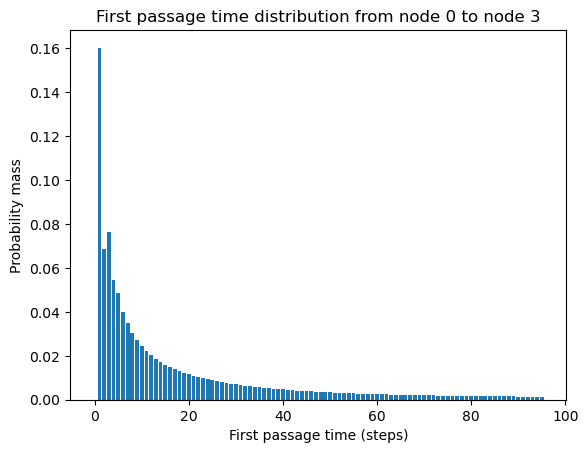

In [413]:
i, j = 0, 3
fpts = fpt_distribution(i, j, G_geo_transitions, stop=1e-3) # Fairly large stop threshold, for visualization purposes
plt.bar(np.arange(len(fpts)), fpts);
plt.title(f'First passage time distribution from node {i} to node {j}')
# plt.xticks(np.arange(len(fpts)));
plt.xlabel('First passage time (steps)')
plt.ylabel('Probability mass')
pass

## Plot geographical network

In [141]:
# Load GADM dataset
gdf_gadm = gpd.read_file('data/gadm41_SOM_2.json.zip')
gdf_gadm = gdf_gadm.to_crs('epsg:20539') # centroids are obtained with more accuracy using a projected CRS
gdf_gadm['centroid'] = gdf_gadm.centroid

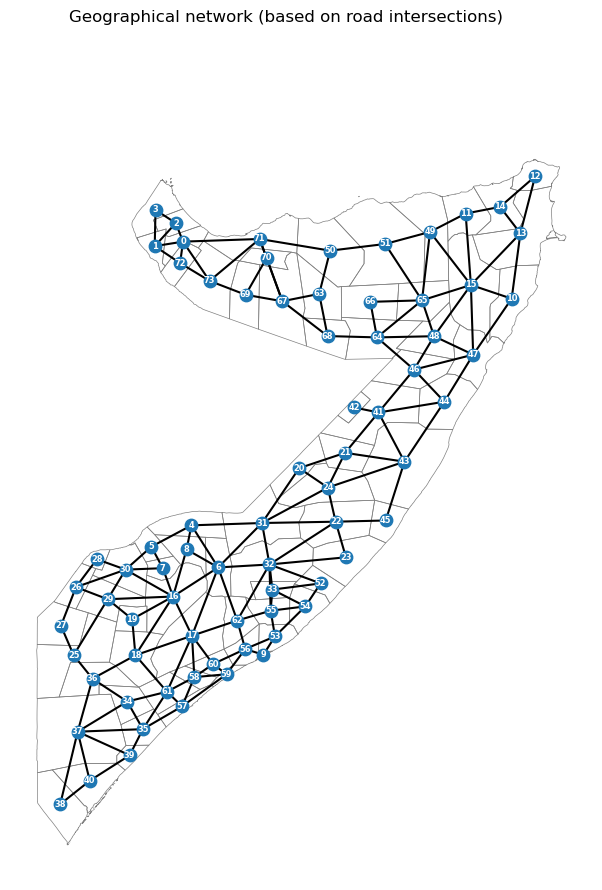

In [420]:
fig, axs = plt.subplots(1, 1, figsize=(12,10))

# Set node positions based on district centroids
pos = {}
for district_id in G_geo.nodes() :
    point = gdf_gadm[gdf_gadm['NAME_2'] == gadm_id_to_label[district_id]]['centroid']
    pos[district_id] = (point.x.values[0], point.y.values[0])

# Plot district borders
gdf_gadm.boundary.plot(ax=axs, linewidth=0.5, color='gray', zorder=0)

# Plot nodes
nx.draw_networkx_nodes(
    G_geo, pos=pos, ax=axs,
    node_size=80,
)
nx.draw_networkx_labels(
    G_geo, pos=pos, ax=axs,
    font_size=6,
    font_color='white',
    font_family='sans-serif',
    font_weight='bold'
)

# Plot edges
nx.draw_networkx_edges(
    G_geo, pos=pos, ax=axs,
    width=1.5
)

axs.set_frame_on(False)

fig.suptitle('Geographical network (based on road intersections)');

# plt.savefig('figs/geo_network.pdf', dpi=600, bbox_inches='tight')
plt.savefig('figs/geo_network.png', dpi=600, bbox_inches='tight')

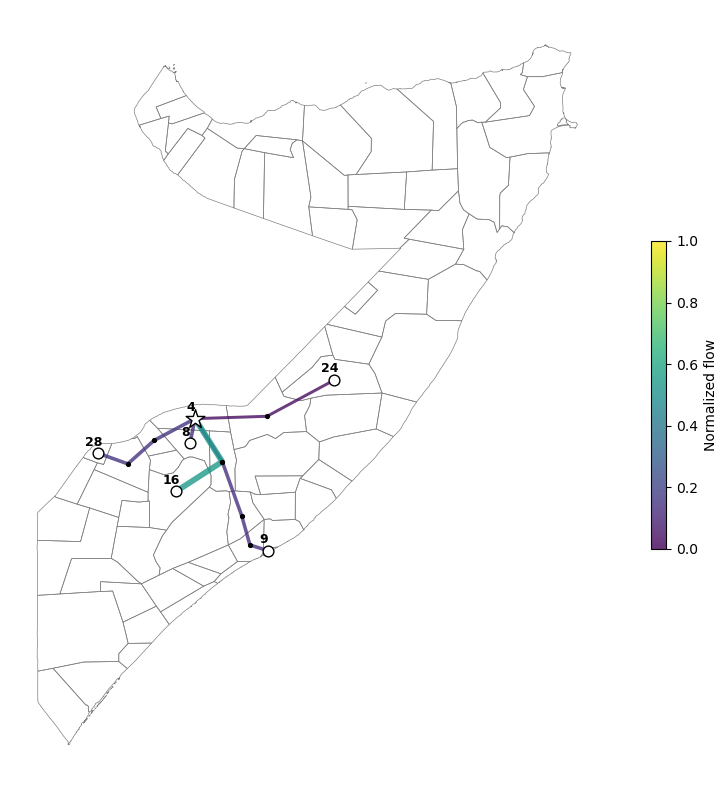

In [418]:
# Plot geographical network with shortest paths between source and target nodes, weighted by normalized flows

def plot_shortest_paths_by_flow(G, origin, ax, pos) :
    # Plot district borders
    gdf_gadm.boundary.plot(ax=ax, linewidth=0.5, color='gray', zorder=0)

    # Plot origin nodes
    nx.draw_networkx_nodes(
        G, pos=pos, ax=ax,
        nodelist=[origin],
        node_shape='*',
        node_size=200,
        node_color='white',
        edgecolors='black',
    )

    flow_neighbors = list(G_flows.successors(origin))

    # Plot destination nodes
    nx.draw_networkx_nodes(
        G, pos=pos, ax=ax,
        nodelist=flow_neighbors,
        node_shape='o',
        node_size=60,
        node_color='white',
        edgecolors='black',
    )

    # Draw labels for origin and destination nodes
    nx.draw_networkx_labels(
        G, pos={n: (x-10000,y+10000) for n, (x,y) in pos.items()}, ax=ax,
        labels={n: n for n in [origin] + flow_neighbors},
        font_size=9,
        font_color='black',
        font_family='sans-serif',
        font_weight='bold',
        verticalalignment='bottom'
    )

    node_outflows = G_flows.out_degree(weight='IDP_flow')

    for destination in flow_neighbors :
        # Get the shortest path between origin and destination
        shortest_path = nx.shortest_path(G, source=origin, target=destination)

        # Plot (vaguely) nodes along path
        nx.draw_networkx_nodes(
            G, pos=pos, ax=ax,
            nodelist=shortest_path[1:-1],
            node_shape='.',
            node_size=30,
            node_color='black'
        )
        
        # Get the weight of the edge in the flow graph normalized by total weight
        flow_normalized = G_flows[origin][destination]['IDP_flow'] / node_outflows[origin]
        
        # Draw the shortest path with width and color proportional to the normalized weight
        lines = nx.draw_networkx_edges(
            G, pos=pos, ax=ax,
            edgelist=[(shortest_path[i], shortest_path[i+1]) for i in range(len(shortest_path)-1)],
            width= 2 + flow_normalized * 4,  # Scale for visibility
            edge_color=[flow_normalized]*(len(shortest_path)-1),
            edge_cmap=plt.cm.viridis,
            edge_vmin=0,
            edge_vmax=1,
            alpha=0.8
        )
    
    ax.set_frame_on(False)

    if flow_neighbors : return lines  # Return the last line drawn for colorbar purposes

origin = 4

fig, ax = plt.subplots(1, 1, figsize=(12,10))

lines = plot_shortest_paths_by_flow(G_geo, origin, ax, pos)

fig.colorbar(lines, ax=ax, label='Normalized flow', shrink=0.4) # Use last line drawn for colorbar

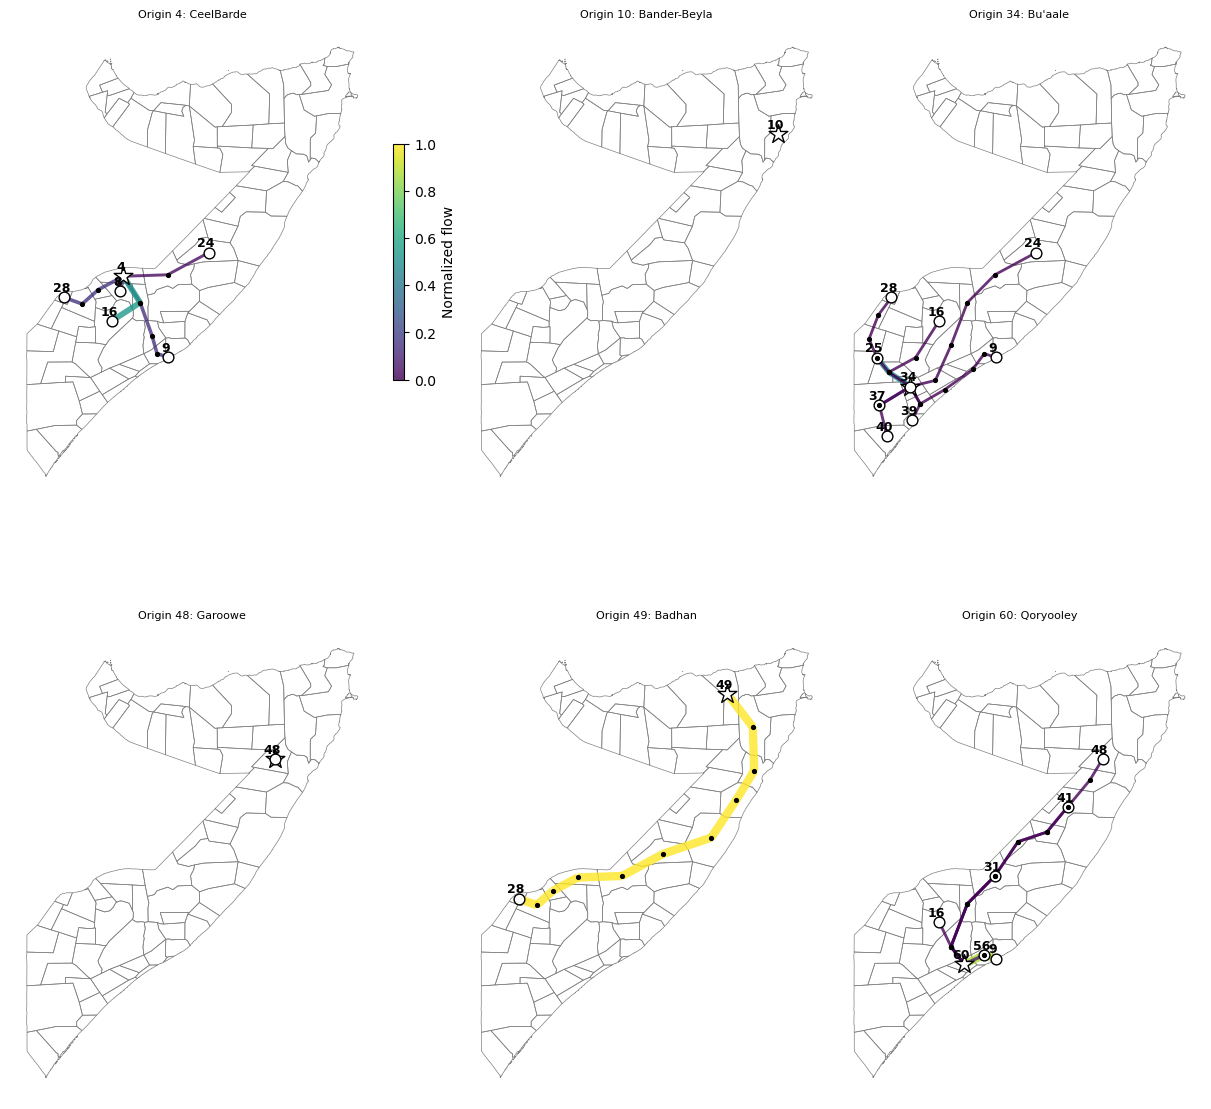

In [423]:
# Create a grid of subplots, one for each node

origins = [4, 10, 34, 48, 49, 60]

n_nodes = len(origins)
n_cols = 3
n_rows = 1 + n_nodes // n_cols

fig, axs = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 6), layout='constrained')
axs_flat = axs.flatten()  # Flatten to make indexing easier

for i, origin in enumerate(origins):
    ax = axs_flat[i]

    lines = plot_shortest_paths_by_flow(G_geo, origin, ax, pos)

    ax.set_title(f'Origin {origin}: {geo_flow_labels[origin, 1]}', fontsize=8)

fig.colorbar(lines, ax=axs_flat[0], label='Normalized flow', shrink=0.4) # Use last line drawn for colorbar

# Hide any unused subplots
for i in range(n_nodes, len(axs_flat)):
    axs_flat[i].set_visible(False)

# plt.tight_layout()

# plt.savefig('figs/shortest_paths_by_flow.pdf', dpi=300)
plt.savefig('figs/shortest_paths_by_flow.png', dpi=600)